<a href="https://colab.research.google.com/github/erigitola/-Random-User--Generator--using--API/blob/main/Cofee_Chain_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df = pd.read_csv('/content/Coffee Chain.csv')

df.head()

,area_ code,cogs,difference _between _actual_target _profit,date,inventory,margin,market _size,market,marketing,???,...,product,profit,sales,state,target_cogs,target_margin,target_profit,target_sales,total_expenses,type
0,303,51,-35,00:00.0,503,71,Major Market,Central,46,1,...,Lemon,-5,122,Colorado,30,60,30,90,76,Decaf
1,970,52,-24,00:00.0,405,71,Major Market,Central,17,1,...,Mint,26,123,Colorado,30,60,50,90,45,Decaf
2,409,43,-22,00:00.0,419,64,Major Market,South,13,1,...,Lemon,28,107,Texas,30,60,50,90,36,Decaf
3,850,38,-15,00:00.0,871,56,Major Market,East,10,1,...,Darjeeling,35,94,Florida,40,60,50,100,21,Regular
4,562,72,6,00:00.0,650,110,Major Market,West,23,1,...,Green Tea,56,182,California,20,60,50,80,54,Regular


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1062 entries, 0 to 1061
Data columns (total 22 columns):
 #   Column                                      Non-Null Count  Dtype 
---  ------                                      --------------  ----- 
 0   area_ code                                  1062 non-null   int64 
 1   cogs                                        1062 non-null   int64 
 2   difference _between _actual_target _profit  1062 non-null   int64 
 3   date                                        1062 non-null   object
 4   inventory                                   1062 non-null   int64 
 5   margin                                      1062 non-null   int64 
 6   market _size                                1062 non-null   object
 7   market                                      1062 non-null   object
 8   marketing                                   1062 non-null   int64 
 9   ???                                         1062 non-null   int64 
 10  product_line            

In [5]:
df.describe()

,area_ code,cogs,difference _between _actual_target _profit,inventory,margin,marketing,???,profit,sales,target_cogs,target_margin,target_profit,target_sales,total_expenses
count,1062.000000,1062.000000,1062.000000,1062.000000,1062.000000,1062.000000,1062.0,1062.000000,1062.000000,1062.000000,1062.000000,1062.000000,1062.000000,1062.000000
mean,587.030132,82.399247,0.387006,815.175141,102.423729,30.433145,1.0,60.556497,191.049906,71.676083,96.817326,60.169492,168.493409,53.836158
std,225.299162,64.824295,44.331180,916.156386,91.286704,25.963448,0.0,100.516593,148.270317,65.701583,89.467176,77.824869,145.955171,31.703526
min,203.000000,0.000000,-369.000000,-3534.000000,-294.000000,0.000000,1.0,-605.000000,21.000000,0.000000,-210.000000,-320.000000,0.000000,11.000000
25%,425.000000,41.000000,-15.000000,447.000000,51.000000,13.000000,1.0,16.250000,98.000000,30.000000,50.000000,20.000000,80.000000,33.000000
50%,573.000000,57.000000,-3.000000,659.000000,73.000000,22.000000,1.0,39.500000,133.000000,50.000000,70.000000,40.000000,120.000000,46.000000
75%,774.000000,101.000000,13.000000,968.000000,130.000000,40.750000,1.0,87.000000,227.000000,90.000000,120.000000,80.000000,210.000000,66.000000
max,985.000000,294.000000,249.000000,8252.000000,526.000000,122.000000,1.0,646.000000,815.000000,380.000000,580.000000,470.000000,960.000000,156.000000


In [6]:
df.shape

(1062, 22)

In [7]:
total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
total_expenses = df['total_expenses'].sum()

total_sales, total_profit, total_expenses

(np.int64(202895), np.int64(64311), np.int64(57174))

In [14]:
#Convert Date column to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df.head()

,area_ code,cogs,difference _between _actual_target _profit,date,inventory,margin,market _size,market,marketing,???,...,product,profit,sales,state,target_cogs,target_margin,target_profit,target_sales,total_expenses,type
0,303,51,-35,2026-01-23,503,71,Major Market,Central,46,1,...,Lemon,-5,122,Colorado,30,60,30,90,76,Decaf
1,970,52,-24,2026-01-23,405,71,Major Market,Central,17,1,...,Mint,26,123,Colorado,30,60,50,90,45,Decaf
2,409,43,-22,2026-01-23,419,64,Major Market,South,13,1,...,Lemon,28,107,Texas,30,60,50,90,36,Decaf
3,850,38,-15,2026-01-23,871,56,Major Market,East,10,1,...,Darjeeling,35,94,Florida,40,60,50,100,21,Regular
4,562,72,6,2026-01-23,650,110,Major Market,West,23,1,...,Green Tea,56,182,California,20,60,50,80,54,Regular


In [12]:
market_summary = df.groupby('marketing')[['sales', 'profit', 'total_expenses']].sum().reset_index()
market_summary.sort_values('profit', ascending=False)

,marketing,sales,profit,total_expenses
31,34,6240,3312,912
22,24,7603,3226,1846
48,66,5528,2561,902
30,33,4923,2435,810
50,70,5497,2333,944
...,...,...,...,...
40,46,996,-63,608
61,96,2274,-127,774
65,113,1375,-370,878
63,109,1320,-372,852


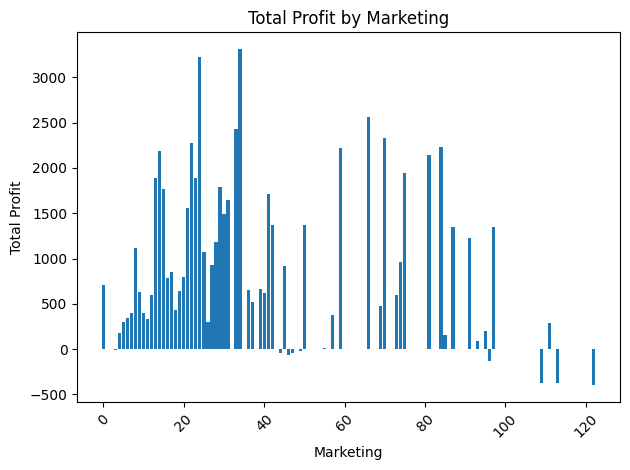

In [18]:
plt.figure()
plt.bar(market_summary['marketing'], market_summary['profit'])
plt.title('Total Profit by Marketing')
plt.xlabel('Marketing')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
product_summary = df.groupby('product')[['sales', 'profit']].sum().reset_index()
product_summary.sort_values('profit', ascending=False)

,product,sales,profit
4,Colombian,30761,12932
10,Lemon,24048,7614
6,Decaf Espresso,18888,7039
3,Chamomile,19295,7006
5,Darjeeling,17758,6976
8,Earl Grey,16546,5975
2,Caffe Mocha,21716,4687
12,Regular Espresso,6744,3438
7,Decaf Irish Cream,14831,3201
1,Caffe Latte,8665,2716


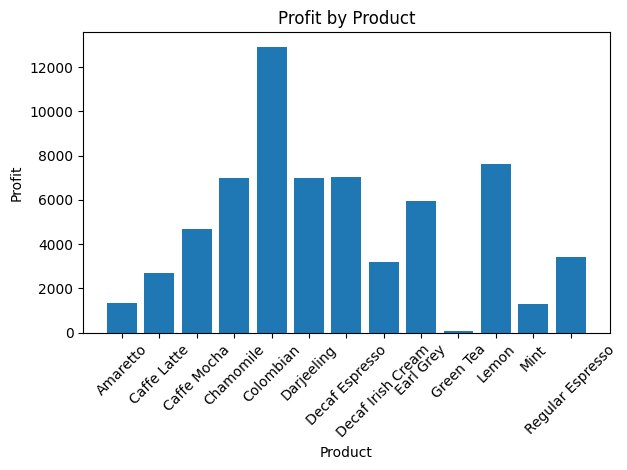

In [23]:
plt.figure()
plt.bar(product_summary['product'], product_summary['profit'])
plt.title('Profit by Product')
plt.xlabel('Product')
plt.ylabel('Profit')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
target_analysis = df.groupby('marketing')[['profit', 'target_profit']].sum().reset_index()
target_analysis['variance'] = target_analysis['profit'] - target_analysis['target_profit']

target_analysis

,marketing,profit,target_profit,variance
0,0,703,660,43
1,3,-14,60,-74
2,4,181,220,-39
3,5,296,440,-144
4,6,345,520,-175
...,...,...,...,...
62,97,1346,1200,146
63,109,-372,-260,-112
64,111,292,120,172
65,113,-370,-120,-250


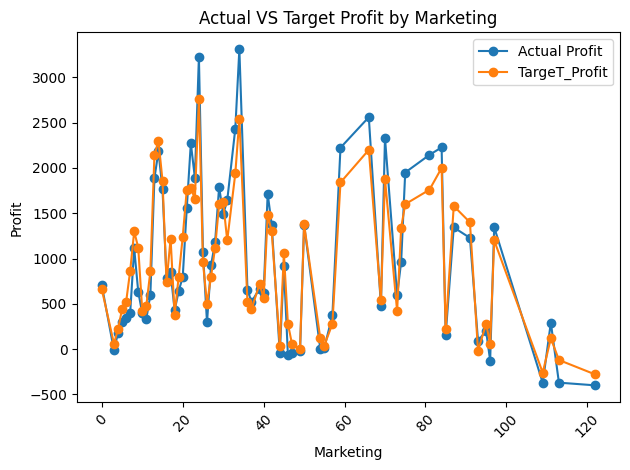

In [31]:
plt.figure()
plt.plot(target_analysis['marketing'], target_analysis['profit'],marker='o', label='Actual Profit')
plt.plot(target_analysis['marketing'], target_analysis['target_profit'], marker='o', label='TargeT_Profit')
plt.title('Actual VS Target Profit by Marketing')
plt.xlabel('Marketing')
plt.ylabel('Profit')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()
